# **NAME**: __________________________________________________________________


# Lab 7: Stereo
In this lab, you will implement window-based stereo and the trick of integral imagea to accelerate it.
Complete the script below and submit this notebook to CatCourse with your own result by **Nov 4 23:59**.

(np.float64(-0.5), np.float64(383.5), np.float64(287.5), np.float64(-0.5))

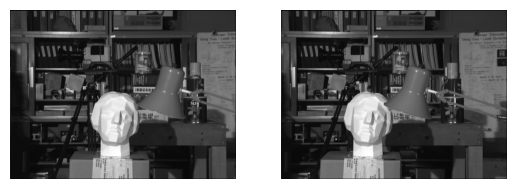

In [ ]:
# Read left image and right image
%matplotlib inline

import numpy as np
import matplotlib
import matplotlib.image as image
import matplotlib.pyplot as plt
from skimage.color import rgb2gray

imL = image.imread("stereo_left.ppm")
imR = image.imread("stereo_right.ppm")
imLgray = rgb2gray(imL)
imRgray = rgb2gray(imR)
plt.subplot(1,2,1)
plt.imshow(imLgray, cmap='gray')
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(imRgray, cmap='gray')
plt.axis("off")

## Part 1: Window-based Stereo Matching

In this section, we will implement a fundamental technique for depth estimation called window-based stereo matching. This method leverages the principle of comparing small image patches, or 'windows', between a pair of rectified stereo images (left and right views) to identify corresponding points. The horizontal displacement between these corresponding points is known as disparity, which is inversely proportional to depth.

Your task is to complete the function `windowed_stereo` below. This function will compute a disparity map, which is an image of the same dimensions as the input images. Each pixel $(y, x)$ in the disparity map will store the calculated disparity value $d$. This value signifies the horizontal shift required in the right image to locate the window that best matches the window centered at $(y, x)$ in the left image. Specifically, the matching window in the right image will be centered at $(y, x-d)$.

To achieve this, we will employ a brute-force search strategy. For every pixel $(y, x)$ in the left image, we will define a local window. We will then compare this left window with a series of windows in the right image, shifted horizontally by potential disparity values $d$, ranging from 0 up to a specified `max_disparity`. The similarity between these windows will be quantified using the Sum of Squared Differences (SSD) metric. The disparity value $d$ that yields the minimum SSD for a given pixel $(y, x)$ will be assigned as the disparity for that pixel in the output map.

### Sum of Squared Differences (SSD)

The Sum of Squared Differences (SSD) is a widely used metric to assess the similarity between two image patches or windows. Given the left image $I$, the right image $I'$, and a potential disparity $d$, the SSD between a window $W$ centered at $(y, x)$ in the left image and a window centered at $(y, x-d)$ in the right image is computed as:

$$ \text{SSD}(y, x, d) = \sum_{(u, v) \in W} (I(y+u, x+v) - I'(y+u, x+v-d))^2 $$

Here, $(u, v)$ represent the coordinates relative to the center of the window. This formula calculates the sum of the squared differences between the intensity values of corresponding pixels within the two windows. A lower SSD value indicates a higher degree of similarity between the windows.

**Complete `windowed_stereo` below. [20 points]**

In [ ]:
def windowed_stereo(imgL, imgR, max_disparity=30, window_size=7):
    """Computes stereo based on sum of differences of two windows on the left and right images.
    """

    W = imgL.shape[1];
    H = imgL.shape[0];
    window_half_size = window_size // 2
    # Create the disparities image:
    Disparities = np.zeros([H, W])

    # Loop over the image
    for x in np.arange(window_half_size, W-window_half_size):

        # In the left border of the left image, not all disparities can be investigated:
        max_disp = np.min([x-window_half_size, max_disparity])
        if max_disp >= 0:
            disps = np.arange(0, max_disp+1);
            differences = np.zeros([len(disps), 1])

            for y in np.arange(window_half_size, H-window_half_size):

                # left window centered at (y, x)
                y0 = y - window_half_size
                y1 = y + window_half_size + 1
                x0 = x - window_half_size
                x1 = x + window_half_size + 1
                window_left = imgL[y0:y1, x0:x1]

                for d in disps:
                    # right window centered at (y, x - d)
                    xr0 = x0 - d
                    xr1 = x1 - d
                    window_right = imgR[y0:y1, xr0:xr1]
                    # SSD between the two windows
                    diff = window_left - window_right
                    differences[d] = np.sum(diff * diff)

                # The minimal difference determines the disparity
                disparity = int(np.argmin(differences))
                Disparities[y, x] = disparity

    return Disparities

**Visualze disparity map, experiment with different window size(window_size=3,5 or 7), and see the different results obtained. Measure the time it takes to compute stereo. [10, 10, 10 points]**

It takes 32.44142436981201 seconds to compute stereo!


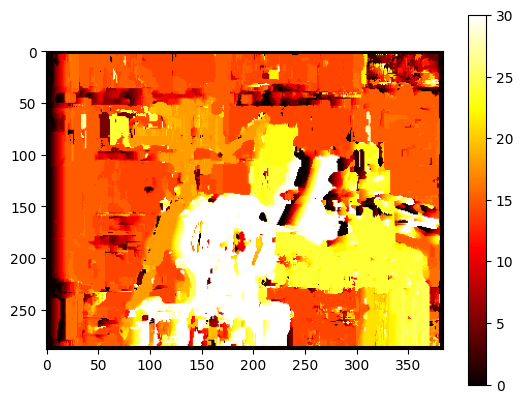

In [ ]:
import time

start=time.time()
disparity_map = windowed_stereo(imLgray, imRgray, max_disparity=30, window_size=7);
print(f"It takes {time.time()-start} seconds to compute stereo!")
plt.figure()
plt.imshow(disparity_map, cmap='hot')
plt.colorbar()
plt.draw()

It takes 32.472068309783936 seconds to compute stereo!


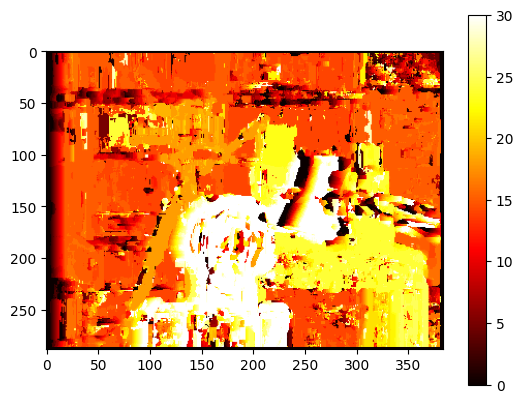

In [ ]:
start=time.time()
disparity_map = windowed_stereo(imLgray, imRgray, max_disparity=30, window_size=5);
print(f"It takes {time.time()-start} seconds to compute stereo!")
plt.figure()
plt.imshow(disparity_map, cmap='hot')
plt.colorbar()
plt.draw()

It takes 36.86079406738281 seconds to compute stereo!


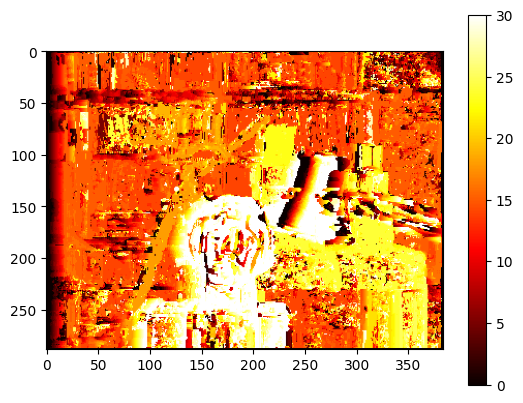

In [ ]:
start=time.time()
disparity_map = windowed_stereo(imLgray, imRgray, max_disparity=30, window_size=3);
print(f"It takes {time.time()-start} seconds to compute stereo!")
plt.figure()
plt.imshow(disparity_map, cmap='hot')
plt.colorbar()
plt.draw()

## Part 2: Acceleration with Integral Images

The window-based stereo matching method we implemented in Part 1 can be computationally expensive, especially for larger window sizes and images. This is because we repeatedly calculate the sum of squared differences over many windows. To speed this up, we can leverage the concept of integral images.

An integral image $f_\text{int}$ is a precomputed image where the value at each pixel $(y, x)$ is the sum of all pixel values in the original image $f$ within the rectangle from the origin $(0, 0)$ up to $(y, x)$. Formally, for an image $f$, the integral image $f_\text{int}$ is defined as:

$$ f_\text{int}(y, x) = \sum_{u=0}^{y} \sum_{v=0}^{x} f(u, v) $$

The key advantage of integral images is that they allow us to compute the sum of pixel values within *any* rectangular window in constant time, regardless of the window size. Given a window defined by its top-left corner $(y_\text{tl}+1, x_\text{tl}+1)$ and its bottom-right corner $(y_\text{br}, x_\text{br})$, the sum of pixels within this window in the original image $f$ can be calculated from the integral image $f_\text{int}$ as follows:

$$ \sum_{u=y_\text{tl}+1}^{y_\text{br}} \sum_{v=x_\text{tl}+1}^{x_\text{br}} f(u, v) = f_\text{int}(y_\text{br}, x_\text{br}) - f_\text{int}(y_\text{tl}, x_\text{br}) - f_\text{int}(y_\text{br}, x_\text{tl}) + f_\text{int}(y_\text{tl}, x_\text{tl}) $$

To apply this to stereo matching with SSD, we will first calculate the squared difference image for each possible disparity $d$:

$$ SD_d(y, x) = (I(y, x) - I'(y, x-d))^2 $$

Then, we compute the integral image for each $SD_d$. The SSD for a window at $(y, x)$ with disparity $d$ can then be calculated in constant time using the integral image of $SD_d$ and the formula above. This avoids recalculating the sum for every window individually.

Complete the function `get_integral_image` below and then use it in `windowed_stereo_fast` to measure the speedup compared to the naive implementation.

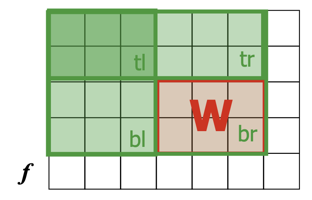

In [ ]:
from PIL import Image
Image.open('integral.png').resize((312, 200))

**First implement a function for integrating a 2D image. [20 points]**

This function will be used in the function `windowed_stereo_fast`.

In [ ]:
def get_integral_image(image):
    H, W = image.shape
    integral_image = np.zeros([H, W])
    for y in np.arange(H):
        for x in np.arange(W):
            # Complete the function here:
            integral_image[y,x] = ...
    return integral_image

# Test the integral function
input = np.array([[0,1,2],[2,3,0],[1,4,2]])
print('Input:\n', input)
print('Integral image:\n', get_integral_image(input))

Input:
 [[0 1 2]
 [2 3 0]
 [1 4 2]]
Integral image:
 [[ 0.  1.  3.]
 [ 2.  6.  8.]
 [ 3. 11. 15.]]


**Apply `get_integral_image` to `windowed_stereo`. [30 points]**

It takes 22.656123876571655 seconds to compute stereo using the trick of integral image!


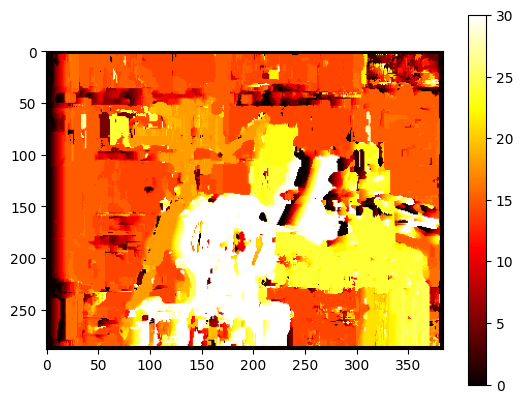

In [ ]:
def windowed_stereo_fast(imgL, imgR, max_disparity=30, window_size=7):

    W = imgL.shape[1]
    H = imgL.shape[0]
    window_half_size = window_size // 2

    # Create the disparities image:
    Disparities = np.zeros([H, W])

    # Calculate squared differences for each disparity
    ssd_images = np.zeros([max_disparity+1, H, W])
    for d in range(max_disparity+1):
        # Complete the function here:
        ssd_images[d] = ...

    # Calculate integral images for each disparity
    integrals = np.zeros([max_disparity+1, H, W])
    for d in range(max_disparity+1):
        # Complete the function here:
        integrals[d] = ...

    # Loop over the image
    for x in np.arange(window_half_size, W-window_half_size):

        # In the left border of the left image, not all disparities can be investigated:
        max_disp = np.min([x-window_half_size, max_disparity])
        if max_disp >= 0:
            disps = np.arange(0, max_disp+1);
            differences = np.zeros([len(disps), 1])

            for y in np.arange(window_half_size, H-window_half_size):

                for d in disps:
                    # Calculate the sum of SSD in the window using integral images
                    # coordinates of the window corners

                    # Complete the function here:
                    differences[d] = ...

                # The minimal difference determines the disparity
                # Complete the function here:
                disparity = ...
                Disparities[y, x] = disparity

    return Disparities

start=time.time()
disparity_map = windowed_stereo_fast(imLgray, imRgray, max_disparity=30, window_size=7)
print(f"It takes {time.time()-start} seconds to compute stereo using the trick of integral image!")
plt.figure()
plt.imshow(disparity_map, cmap='hot')
plt.colorbar();
plt.draw()